In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df=pd.read_csv("supply_chain_data.csv")
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [ ]:
df.isnull().sum()

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0


In [ ]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [ ]:
df.dtypes

,0
Product type,object
SKU,object
Price,float64
Availability,int64
Number of products sold,int64
Revenue generated,float64
Customer demographics,object
Stock levels,int64
Lead times,int64
Order quantities,int64


In [ ]:
df.shape

(100, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
print(df['revenue_generated'].sum()) #Total revenue generated

577604.8187380086


In [ ]:
print(df['number_of_products_sold'].sum()) #total products sold

46099


In [ ]:
print(df['shipping_costs'].mean()) #average shipping cost

5.548149072019588


In [ ]:
top_products = df.groupby('product_type')['number_of_products_sold'].sum().sort_values(ascending=False)

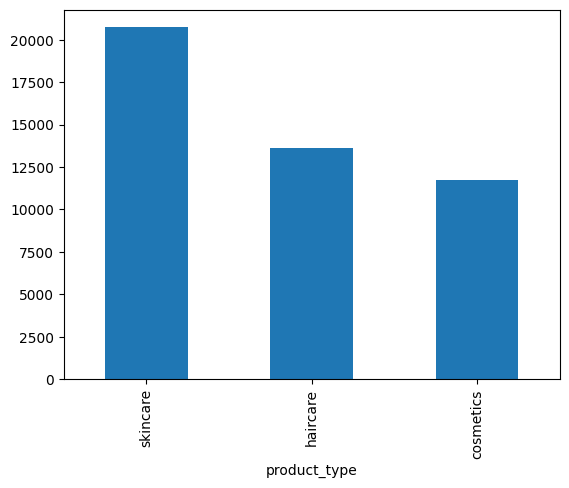

In [ ]:
top_products.plot(kind='bar')
plt.show()

In [ ]:
overstock = df[df['stock_levels'] > df['number_of_products_sold']]

In [ ]:
print(overstock)

   product_type    sku      price  availability  number_of_products_sold  \
45     haircare  SKU45  33.784138             1                       24   
48     haircare  SKU48  76.035544            28                       29   

    revenue_generated customer_demographics  stock_levels  lead_times  \
45        5267.956808                  Male            93           7   
48        7397.071005            Non-binary            30          16   

    order_quantities  ...  location lead_time  production_volumes  \
45                52  ...   Chennai        25                 794   
48                 9  ...    Mumbai         9                 109   

   manufacturing_lead_time manufacturing_costs  inspection_results  \
45                      25           66.312544                Pass   
48                      18           23.126364                Fail   

    defect_rates  transportation_modes   routes       costs  
45      3.219605                  Rail  Route A  495.305697  
48      

In [ ]:
stockout_risk = df[(df['stock_levels'] < 20) & (df['number_of_products_sold'] > 100)]

In [ ]:
supplier_performance = df.groupby('supplier_name')['lead_times'].mean()
print(supplier_performance)

supplier_name
Supplier 1    16.777778
Supplier 2    16.227273
Supplier 3    14.333333
Supplier 4    17.000000
Supplier 5    14.722222
Name: lead_times, dtype: float64


In [ ]:
supplier_defects = df.groupby('supplier_name')['defect_rates'].mean()
print(supplier_defects)

supplier_name
Supplier 1    1.803630
Supplier 2    2.362750
Supplier 3    2.465786
Supplier 4    2.337397
Supplier 5    2.665408
Name: defect_rates, dtype: float64


In [ ]:
transport_cost = df.groupby('transportation_modes')['shipping_costs'].mean()
print(transport_cost)

transportation_modes
Air     6.017839
Rail    5.469098
Road    5.542115
Sea     4.970294
Name: shipping_costs, dtype: float64


In [ ]:
carrier_delay = df.groupby('shipping_carriers')['shipping_times'].mean()
print(carrier_delay)

shipping_carriers
Carrier A    6.142857
Carrier B    5.302326
Carrier C    6.034483
Name: shipping_times, dtype: float64


In [ ]:
revenue_by_product = df.groupby('product_type')['revenue_generated'].sum()
print(revenue_by_product)

product_type
cosmetics    161521.265999
haircare     174455.390605
skincare     241628.162133
Name: revenue_generated, dtype: float64


In [ ]:
manufacturing_cost = df.groupby('product_type')['manufacturing_costs'].mean()
print(manufacturing_cost)

product_type
cosmetics    43.052740
haircare     48.457993
skincare     48.993157
Name: manufacturing_costs, dtype: float64


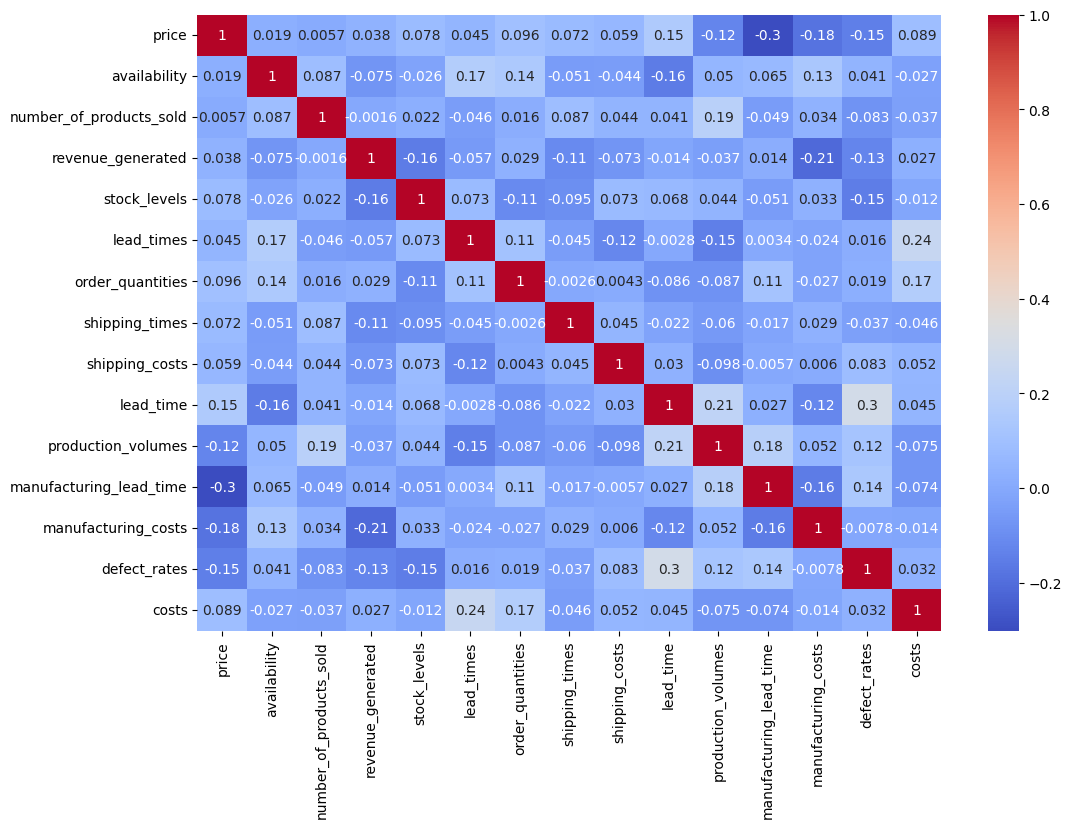

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
X = df[
    [
        'stock_levels',
        'lead_times',
        'shipping_costs',
        'manufacturing_costs',
        'defect_rates',
        'revenue_generated'
    ]
]
y = df['number_of_products_sold']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 320.1283103844827
RMSE: 347.9746442573325
R2 Score: -0.2688296647668884


In [ ]:
df['Predicted Demand'] = model.predict(X)

In [ ]:
df.head()

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs,Predicted Demand
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,488.620521
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,447.088829
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,385.542421
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,382.667397
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,362.911810


In [ ]:
df.to_csv("forecasted_supply_chain.csv", index=False)